# Assignment 5: Reducing High-Dimensional Data with PCA

**Student Name:** Reagan O

**Date:** 3/1/26

---

## Assignment Overview

You've joined the data science team at FitTrack Analytics, a company that develops fall detection systems for elderly care facilities. Their wearable devices capture 561 sensor features from accelerometer and gyroscope readings. Your task: use Principal Component Analysis (PCA) to compress this high-dimensional data into something you can visualize, understand, and build reliable models from.

---

## Step 1: Import Libraries and Load Data

In [13]:
python3 install pandas matplotlib seaborn scikit-learn
pip install --upgrade pip



SyntaxError: invalid syntax (2489532502.py, line 1)

In [14]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [18]:
# Load the Human Activity Recognition dataset
# TODO: Load train.csv and test.csv from the data folder
train_df = pd.read_csv('data/train.csv')  # Replace with pd.read_csv()
test_df = pd.read_csv('data/test.csv')   # Replace with pd.read_csv()

# TODO: Separate features from labels
# Create X_train, y_train, X_test, y_test
# The 'Activity' column contains the labels
X_train =  train_df.drop('Activity', axis=1)
y_train = train_df['Activity']
X_test = test_df.drop('Activity', axis=1)
y_test = test_df['Activity']

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape if X_train is not None else 'Not loaded'}")
print(f"Test set shape: {X_test.shape if X_test is not None else 'Not loaded'}")
print(f"Number of features: {X_train.shape[1] if X_train is not None else 'N/A'}")
print(f"Unique activities: {y_train.nunique() if y_train is not None else 'N/A'}")
print("="*80)


CHECKPOINT: Verify dataset loaded correctly
Training set shape: (7352, 562)
Test set shape: (2947, 562)
Number of features: 562
Unique activities: 6


---
## Step 2: Experience the Problem - Try to Understand 561 Dimensions

### Attempt Visualization with 2 Features

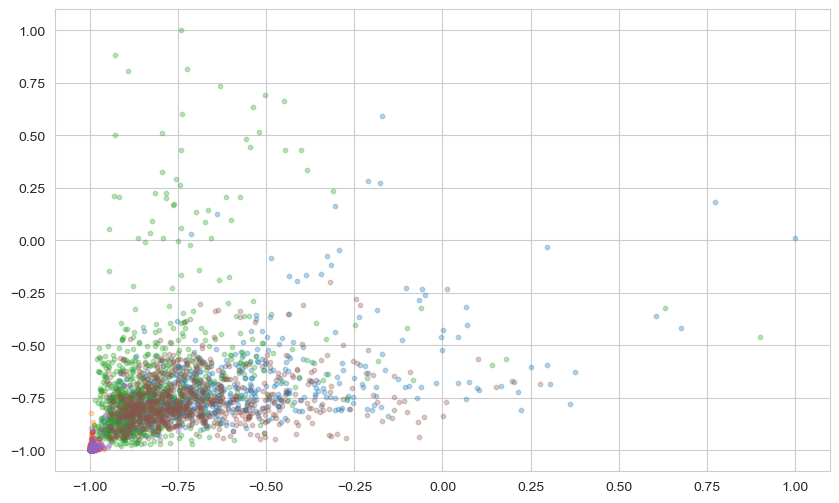

In [26]:
# TODO: Create a scatter plot using any 2 of the 561 features
# Color points by activity type
# Can you see clear patterns separating the six activities?

# Label names for the 10 classes
label_names = {0: 'STANDING', 1: 'SITTING', 2: 'LAYING', 3: 'WALKING', 4: 'WALKING_DOWNSTAIRS',
               5: 'WALKING_UPSTAIRS'}

# Try plotting pixel 400 vs pixel 500 (arbitrary choices)
# Sample 5000 points to make the plot readable
sample_size = 5000
sample_indices = np.random.choice(len(X_train), sample_size, replace=False)
X_sample = X_train.iloc[sample_indices]
y_sample = y_train.iloc[sample_indices]

string_labels = y_sample.unique()
label_to_id = {label: idx for idx, label in enumerate(string_labels)}

# Map string labels to numbers
y_numeric = y_sample.map(label_to_id)

plt.figure(figsize=(10, 6))
for class_id in range(6):
    mask = y_numeric == class_id
    plt.scatter(X_sample[mask].iloc[:, 400], X_sample[mask].iloc[:, 500], 
                alpha=0.3, s=10, label=label_names[class_id])



### Check Feature Correlations

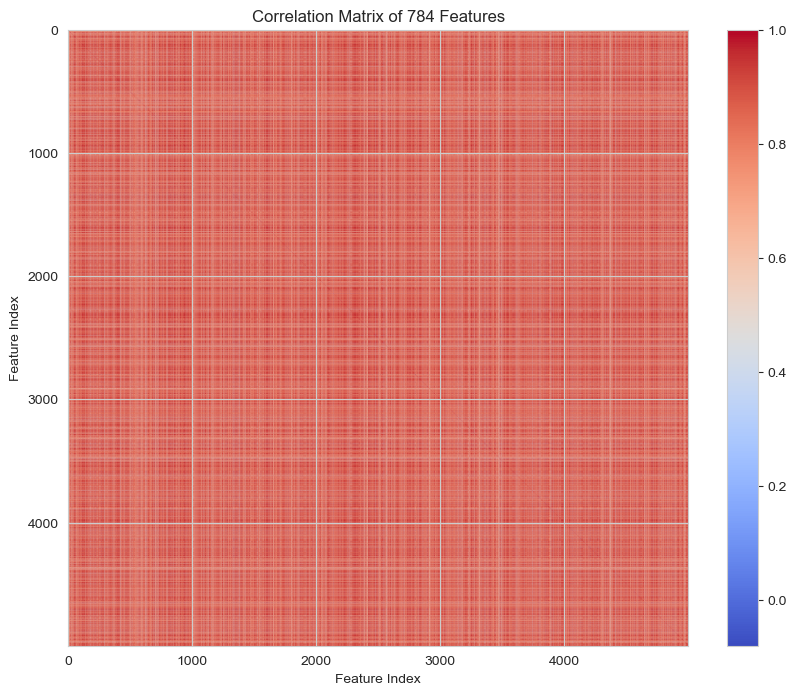

In [27]:
# TODO: Create a correlation heatmap of all 561 features
# Is it readable? Can you identify redundant features?

# Sample 5000 images to make computation manageable
sample_indices = np.random.choice(len(X_train), 5000, replace=False)
X_sample = X_train.iloc[sample_indices]

# Calculate correlation matrix
corr_matrix = X_sample.T.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.title('Correlation Matrix of 784 Features')
plt.xlabel('Feature Index')
plt.ylabel('Feature Index')
plt.show()


### Train Baseline Model

In [28]:
start_time = time.time()

# TODO: Train a RandomForestClassifier with n_estimators=100, random_state=42
# Your code here
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

baseline_model.fit(X_train, y_train)


# Calculates baseline training time
baseline_time = time.time() - start_time

# TODO: Calculate accuracy on test set
y_pred = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print(f"Number of features: {X_train.shape[1]}")
print(f"Accuracy: {baseline_accuracy if baseline_accuracy else 'Not calculated'}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)


BASELINE MODEL RESULTS
Number of features: 562
Accuracy: 0.9260264675941635
Training time: 2.07 seconds


### Reflection on High-Dimensional Data
In the Markdown cell below this step, write 2-3 sentences responding to the following question: 
- What problems did you encounter trying to understand 561 dimensions?

Since there was 561 dimensions, this makes it hard to interpret. We really cannot see true patterns easily.

---
## Step 3: Apply PCA to Visualize in 2D and 3D

### Standardize Features

In [29]:
# TODO: Use StandardScaler to normalize all 562 features
# Fit on training data, transform both training and test data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Replace with scaled training data using scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Replace with scaled test data using scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Scaled training shape: {X_train_scaled.shape if X_train_scaled is not None else 'Not scaled'}")
print("="*80)


CHECKPOINT: Features Standardized
Scaled training shape: (7352, 562)


### Apply PCA for 2 Components

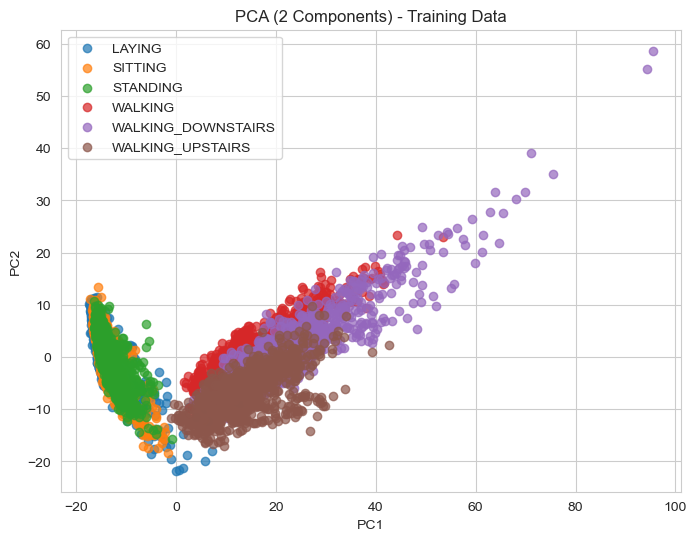

In [37]:
# TODO: Use PCA(n_components=2)
# Fit on standardized training data, transform both sets

pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)  # Replace with PCA-transformed training data using pca_2d.fit_transform(X_train_scaled)
X_test_pca_2d = pca_2d.transform(X_test_scaled)  # Replace with PCA-transformed test data using pca_2d.transform(X_test_scaled)

# TODO: Create scatter plot using the 2 principal components
# Color by activity type, add title, axis labels (PC1, PC2), and legend
plt.figure(figsize=(8, 6))

# Get unique activity labels
activities = np.unique(y_train)

for activity in activities:
    idx = y_train == activity
    plt.scatter(
        X_train_pca_2d[idx, 0],
        X_train_pca_2d[idx, 1],
        label=activity,
        alpha=0.7
    )

plt.title("PCA (2 Components) - Training Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()


### Apply PCA for 3 Components

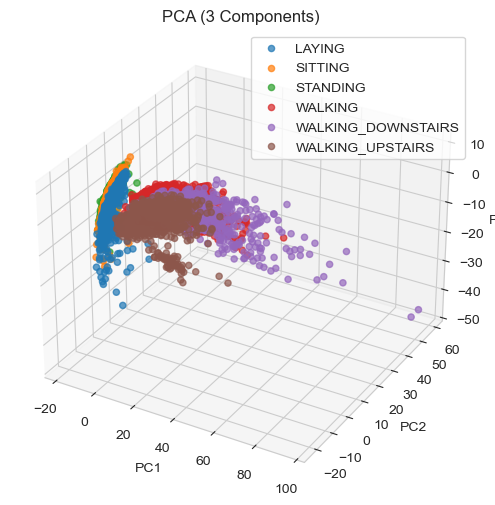

In [41]:
# TODO: Use PCA(n_components=3)
# Fit on standardized training data, transform both sets

pca_3d = PCA(n_components=3)
X_train_pca_3d = pca_3d.fit_transform(X_train_scaled)  # Replace with PCA-transformed training data using pca_3d.fit_transform(X_train_scaled)
X_test_pca_3d = pca_3d.transform(X_test_scaled)   # Replace with PCA-transformed test data using pca_3d.transform(X_test_scaled)

# TODO: Create 3D scatter plot using the 3 principal components
# Use mpl_toolkits.mplot3d.Axes3D
# Color by activity type


import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

activities = np.unique(y_train)

for activity in activities:
    idx = y_train == activity
    ax.scatter(
        X_train_pca_3d[idx, 0],
        X_train_pca_3d[idx, 1],
        X_train_pca_3d[idx, 2],
        label=activity,
        alpha=0.7
    )

ax.set_title("PCA (3 Components)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.legend()
plt.show()




### Reflection on PCA Visualization
In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- What activity patterns can you now see? 
- Which activities cluster together?

I can now see clustering like overlap. For instance, walking, walking upstairs, and walking downstairs overlap which makes sense since they all deal with walking. I do see sitting stays all together wheras walking downstairs is the most spread out. 

---
## Step 4: Determine Optimal Number of Components Using Explained Variance

### Create Scree Plot

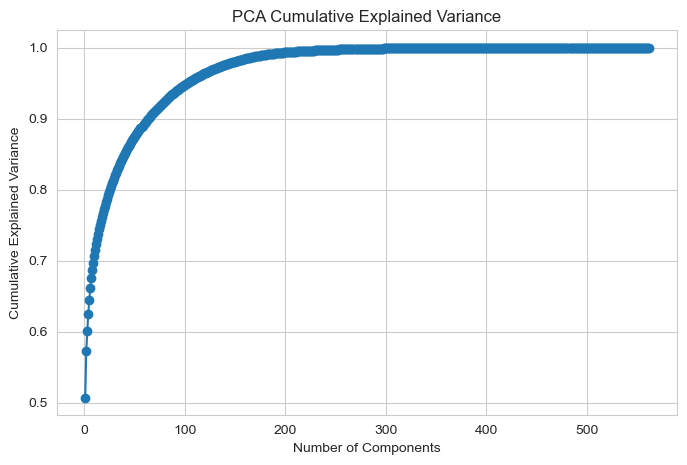

In [46]:
# Fit PCA(n_components=100) to standardized training data
pca_full = PCA(n_components=100)
pca_full.fit(X_train_scaled)

# Apply PCA with ALL components to see full variance distribution
pca_full = PCA()  # No n_components specified = all components
pca_full.fit(X_train_scaled)

# Get explained variance for each component
explained_variance = pca_full.explained_variance_ratio_
n_components_total = len(explained_variance)

# TODO: Plot explained variance ratio for each component
# Use pca_full.explained_variance_ratio_ to get the ratios
# Use np.cumsum() to compute cumulative variance 



cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot
plt.figure(figsize=(8,5))
plt.plot(
    np.arange(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()



# TODO: Plot cumulative explained variance



### Analyze the Elbow

In [49]:
# TODO: Identify how many components capture 75%, 80%, and variance
# You can use pca_full.explained_variance_ratio_ and np.cumsum()

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

components_75 = np.argmax(cumulative_variance >= 0.75) + 1  # Replace with number of components for 75%
components_80 =  np.argmax(cumulative_variance >= 0.80) + 1  # Replace with number of components for 80%
components_90 = np.argmax(cumulative_variance >= 0.90) + 1  # Replace with number of components for 90%

print("\n" + "="*80)
print("EXPLAINED VARIANCE ANALYSIS")
print(f"Components for 75% variance: {components_75}")
print(f"Components for 80% variance: {components_80}")
print(f"Components for 90% variance: {components_90}")
print("="*80)


EXPLAINED VARIANCE ANALYSIS
Components for 75% variance: 16
Components for 80% variance: 26
Components for 90% variance: 64


### Select Optimal Components

In [50]:
# TODO: Set your chosen optimal number of components
optimal_components = components_75  # Replace with your chosen value (components_75, components_80, or components_90)

print(f"Chosen number of components: {optimal_components}")

Chosen number of components: 16


In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- How many components did you select based on the elbow? 
- What percentage of variance does this capture? 
- What's the tradeoff?

I chose 16. This captures 75% of the variance. The trade off is how I could have gotten rid of a minor but useful signal, but with less data this means the model will run faster and be more efficent to users. 

---
## Step 5: Compare Model Performance - Original vs PCA Features

### Transform Data with Optimal Components

In [52]:
# TODO: Apply PCA with your optimal number of components
# Fit on standardized training data, transform both sets

pca_optimal = PCA(n_components=optimal_components)
X_train_pca = pca_optimal.fit_transform(X_train_scaled)  # Replace with PCA-transformed training data
X_test_pca = pca_optimal.transform(X_test_scaled)  # Replace with PCA-transformed test data

print("\n" + "="*80)
print("CHECKPOINT: Data Transformed with Optimal Components")
print(f"New feature dimensions: {X_train_pca.shape if X_train_pca is not None else 'Not transformed'}")
print("="*80)


CHECKPOINT: Data Transformed with Optimal Components
New feature dimensions: (7352, 16)


### Train PCA Model

In [ ]:
# To measure training time
start_time = time.time()

# TODO: Train RandomForestClassifier with same parameters
# Use n_estimators=100, random_state=42
# Use X_train_pca and y_train
pca_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Fit model using PCA-transformed data
pca_model.fit(X_train_pca, y_train)

# Predict on test set
y_pred = pca_model.predict(X_test_pca)




# TODO: Calculate accuracy on test set
pca_accuracy = accuracy_score(y_test, y_pred)

# Record: accuracy, training time, number of features
pca_time = time.time() - start_time


print("\n" + "="*80)
print("PCA MODEL RESULTS")
print(f"Number of features: {optimal_components}")
print(f"Accuracy: {pca_accuracy if pca_accuracy else 'Not calculated'}")
print(f"Training time: {pca_time:.2f} seconds")
print("="*80)


PCA MODEL RESULTS
Number of features: 16
Accuracy: 0.8445877163216831
Training time: 2.67 seconds


### Create Comparison Table

In [55]:
# Create comparison table showing:
# - Number of features
# - Accuracy
# - Training time

comparison_df = pd.DataFrame({
    'Model': ['Baseline (All Features)', 'PCA Model'],
    'Features': [561, optimal_components],
    'Accuracy': [baseline_accuracy, pca_accuracy],
    'Training Time (s)': [baseline_time, pca_time]
})

# TODO: Calculate speedup factor
speedup = baseline_time / pca_time  # Replace with baseline_time / pca_time

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print(f"\nSpeedup factor: {speedup:.2f}x" if speedup else "\nSpeedup not calculated")
print("="*80)


MODEL COMPARISON
                  Model  Features  Accuracy  Training Time (s)
Baseline (All Features)       561  0.926026           2.073863
              PCA Model        16  0.844588           2.671865

Speedup factor: 0.78x


### Final Analysis

In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- Did PCA improve or hurt accuracy? 
- How much faster was training? 
- When would you recommend using PCA?

[Write your response here. What did you gain (speed, interpretability) and what did you lose (if anything)? In what production scenarios would you recommend dimensionality reduction?] With PCA, the model was more easy to interpret (16 features vs over 500). However the trade off was this, was it took a little bit longer and was less accurate by less than 10%. PCA took exactly 60 secs longer. I recommend using PCA when a person has a lot of data and needs to see correlations easily. I don't think this is a good idea for the final answer especially if it deals with important info like patients after a surgery. More analysis must be conducted after PCA especially since it's so hard to interpret and it's hard to communicate findings with people who are not familiar with PCA. 

---
## Step 6: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline model with metrics recorded
   - 2D and 3D PCA visualizations
   - Scree plot with explained variance
   - Optimal component selection with justification
   - Model comparison table
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed PCA dimensionality reduction assignment'
git push
```

Submit your GitHub repository link on the course platform.